# Verification — is the published result correct?

**This notebook needs no solver and no licence.** It reads committed numbers and checks them
against the published ones. Nothing here re-solves anything, which is the point: a claim that
the published result is correct should be checkable by a reader who cannot run the model.

The companion notebook, [`01_example.ipynb`](01_example.ipynb), does the opposite — it builds
and solves the model with a free solver, and shows that the implementation behaves.

| | needs | claims |
|---|---|---|
| `archive/gams-base-model/` | GAMS + CPLEX | produced the published result |
| `src/water_energy/` | a solver | reproduces it |
| **this notebook** | **nothing** | **the published result is correct** |
| `01_example.ipynb` | a free solver | the implementation runs and behaves |

**What it checks, and what it cannot.** It checks the base household model end to end. It
*cannot* check the full co-optimisation model behind the paper's figures — that model is
799,394 × 900,467, needs a commercial solver, and reads inputs that are not distributable.
Those numbers are transcribed here and labelled as transcribed. Sections 5 and 6 say so plainly.

In [1]:
# Colab: install the package straight from the published tag. Everything else is stdlib.
# The tag matters - `main` moves, and a notebook that follows a branch silently changes
# its answer when somebody edits a table.
try:
    import water_energy  # noqa: F401
except ImportError:
    %pip install -q "git+https://github.com/sear-labs/water-energy-coopt-scs-2021@v1.0.0"
    import water_energy  # noqa: F401

## Where the numbers come from

Two sources, and they are deliberately different kinds of thing.

- **`water_energy.reference`** holds the *published* values — transcribed by hand from the GAMS
  run and from the paper. Nothing in it is computed.
- **`water_energy.tables`** reads the *reproduced* values from `results/tables/`, which are
  committed to the repository so that this notebook works from a clean clone. Running in Colab
  with no clone, it falls back to the published copy at the release tag.

Local always wins over the published copy. That is not a preference: if the remote copy won,
a reader who re-solved and edited a table would be told the published numbers with nothing
reporting it.

In [2]:
from water_energy import reference as R
from water_energy import tables

print(tables.source())

local: C:\Users\jonesec\dev\repo\projects\water-energy-coopt-scs-2021\results\tables


## 1. The base model reproduces the GAMS optimum

The Python port's answer, read from committed output, against the GAMS/CPLEX run in
`archive/gams-base-model/`. That run used `optcr = 0` **and** `optca = 0`, so its optimum is
*proven* rather than accepted inside a band — which is what makes it a valid target for a
different solver. A gap-tolerant reference would not be: another solver returns a different
incumbent inside the same band, and the comparison would measure the band, not the model.

In [3]:
summary = tables.load_summary("base")
delta = abs(summary["objective"] - R.GAMS_OBJECTIVE)

print(f"GAMS / CPLEX   {R.GAMS_OBJECTIVE:>14,.4f}")
print(f"Python port    {summary['objective']:>14,.4f}")
print(f"difference     {delta:>14.2e}   tolerance {R.TOL_OBJECTIVE:.0e}")

assert delta < R.TOL_OBJECTIVE, f"the port no longer reproduces the published optimum: {delta}"
print("\nOK - objectives agree")

GAMS / CPLEX      30,336.4771
Python port       30,336.4771
difference           0.00e+00   tolerance 1e-03

OK - objectives agree


**Why the tolerance is `1e-3` and not something tighter.** The GAMS report writer emitted four
decimal places, so `1e-3` is what the *recorded value* supports. The solve itself is exact —
both sides run at a MIP gap of zero. Asserting `1e-9` here would be claiming precision the
reference does not carry, and a tolerance placed below the noise reports the noise.

## 2. The whole solution, not only the objective

Two implementations of one model agree on the objective. They will not necessarily agree on
every variable, and demanding that manufactures failures — degenerate problems have alternate
optima, and a variable that nothing constrains and nothing costs is simply not determined.

Here they agree on everything the optimum *determines*, which is not quite the same as
everything — see below the table.

In [4]:
adoption = tables.load_adoption("base")
invest = tables.load_investment("base")

print(f"{'tech':<6}{'invested':>10}{'published':>12}{'reproduced':>12}{'ok':>5}")
worst = 0.0
for tech in R.GAMS_Y:
    d = abs(adoption[tech] - R.GAMS_Y[tech])
    worst = max(worst, d)
    determined = tech in R.Y1_DETERMINED
    same_binary = invest[tech] == R.GAMS_Y1[tech]
    mark = "  yes" if (d < R.TOL_SOLUTION and same_binary) else "  NO"
    print(f"{tech:<6}{invest[tech]:>10}{R.GAMS_Y[tech]:>12.4f}{adoption[tech]:>12.4f}"
          f"{mark:>5}{'' if determined else '   (binary undetermined)'}")

assert worst < R.TOL_SOLUTION, f"adoption levels diverge by {worst}"
for tech in R.Y1_DETERMINED:
    assert invest[tech] == R.GAMS_Y1[tech], f"{tech}: investment decision differs"
print(f"\nOK - worst difference {worst:.2e} across every adoption level,")
print(f"     and every determined binary matches ({', '.join(R.Y1_DETERMINED)})")

tech    invested   published  reproduced   ok
RWI            1      6.4935      6.4935  yes
RWO            1     24.4683     24.4683  yes
HGW            1      0.0000      0.0000  yes   (binary undetermined)
CGW            1    100.0000    100.0000  yes
CSW            0      0.0000      0.0000  yes

OK - worst difference 0.00e+00 across every adoption level,
     and every determined binary matches (RWI, RWO, CGW, CSW)


### One binary is not determined, and it is not asserted

`y1["HGW"]` can be 0 or 1 with no effect. Household technologies are costed on the number of
adopters, not on the buy decision, and HGW adopts nobody — so the variable appears in no cost
term and both of its big-M rows have a left-hand side of zero. Forcing it each way gives
`30336.477068` both times, identical to every digit.

GAMS returned 1 and the Python port returns 1, so the two "agree". That agreement is a
coincidence of which vertex each solver walked to, and asserting it would be testing the solver
rather than the model — the kind of check that holds for months on one machine and goes red the
first time it runs somewhere else. It is left out of the assertion above and recorded in
`reference.py` instead, with the measurement.

## 3. An invariant the table has to satisfy on its own

The two checks above compare the table with an external reference. This one needs no reference
at all: the three cost components are the objective, decomposed, so they must add up. It would
catch a table written from one run and a summary written from another — the kind of mismatch
that no comparison against a published number can see.

In [5]:
parts = ["capital_cost", "water_cost", "energy_cost"]
total = sum(summary[p] for p in parts)

for p in parts:
    print(f"{p:<16}{summary[p]:>12,.4f}   {summary[p] / summary['objective']:>6.1%}")
print(f"{'sum':<16}{total:>12,.4f}")
print(f"{'objective':<16}{summary['objective']:>12,.4f}")

assert abs(total - summary["objective"]) < 1e-3, "cost components do not sum to the objective"
print("\nOK - the decomposition closes")

capital_cost     21,543.4259    71.0%
water_cost        8,268.8870    27.3%
energy_cost         524.1642     1.7%
sum              30,336.4771
objective        30,336.4771

OK - the decomposition closes


## 4. The full co-optimisation model — transcribed, not reproduced

The paper's headline numbers come from `model-gams/`, not from the base model above. Three
facts about it, and none of them is checkable here:

- It is **799,394 × 900,467** and needs a commercial solver.
- Its inputs are Pecan Street–derived and **not distributable**; a synthetic instance ships in
  their place.
- It has **no Python implementation**. The port covers the base model only.

So the numbers below are recorded, not verified. What *is* checkable is the arithmetic relating
them — and both quantities matter, because each is an argument the paper makes.

In [6]:
print(f"proven optimum        (optcr=0, optca=0)   {R.FULL_MODEL_PROVEN_OPTIMUM:>15,.4f}")
print(f"as the original ran   (optcr=0.05)         {R.FULL_MODEL_AT_OPTCR_05:>15,.4f}")
print(f"synthetic instance                         {R.FULL_MODEL_SYNTHETIC:>15,.2f}")
print()
print(f"cost of the original's gap setting   {R.full_model_gap_cost():>+8.3%}")
print(f"error from synthesising the inputs   {R.full_model_synthetic_error():>+8.3%}"
      f"   (tolerance {R.TOL_SYNTHETIC_RELATIVE:.0%})")

assert abs(R.full_model_synthetic_error()) < R.TOL_SYNTHETIC_RELATIVE
print("\nOK - the synthetic instance is inside the agreed tolerance")

proven optimum        (optcr=0, optca=0)    1,005,948.1924
as the original ran   (optcr=0.05)          1,009,606.8517
synthetic instance                            1,002,084.10

cost of the original's gap setting    +0.364%
error from synthesising the inputs    -0.384%   (tolerance 5%)

OK - the synthetic instance is inside the agreed tolerance


Read those two percentages together. The gap setting the original shipped with cost **more**
accuracy than replacing every input with synthetic data did — 0.364% against 0.384%, the same
order. That is the argument for `MIPGap = 0` throughout the Python port: a tolerance loose
enough to be invisible in the logs was doing as much damage as throwing the real data away.

## 5. What this notebook cannot check

Stated explicitly, because a verification notebook that is silent about its limits invites the
reader to over-read it.

1. **The published figures, by you.** `figures/*.pdf` were drawn by `archive/figures-r/` from
   the raw solver output of the full model, on restricted inputs. Neither the inputs nor the
   R workspace image is distributed, so *a reader* cannot regenerate them. The author can, and
   did on 2026-09-11: the archived R was re-run and reproduced six of the published figures bar
   for bar. The committed PDFs are the artifacts of record and were left as they are.
2. **The full model's own optimality.** Section 4 transcribes it. Only a commercial solver and
   the real workbooks could confirm it.
3. **The step that produced the aggregates**, though not the aggregates themselves — see below.

What *is* established above: the base model's published optimum is correct, its full solution
vector is correct, its cost decomposition closes, and the synthetic instance lands inside the
tolerance agreed for it.

## 6. The paper's own aggregates, which you can check here

The full model's per-scenario results were extracted from the archived R workspace and committed
to `results/tables/published/` — 31 tables covering cost, capacity, production and demand
fractions, across five system configurations and four community sizes. They need no R, no GAMS
and no restricted input to read.

They are *evidence*, not a reproduction: nothing in this repository re-derives them, because the
model that produced them is not reimplemented. What they let you do is check the paper's figures
against the numbers behind them.

In [7]:
import csv, io as _io, urllib.request
from pathlib import Path

BASE = "https://raw.githubusercontent.com/sear-labs/water-energy-coopt-scs-2021/v1.0.0"
def published(name):
    local = Path.cwd().parent / "results" / "tables" / "published" / f"{name}.csv"
    text = (local.read_text(encoding="utf-8") if local.exists()
            else urllib.request.urlopen(f"{BASE}/results/tables/published/{name}.csv")
                 .read().decode("utf-8"))
    return list(csv.DictReader(_io.StringIO(text)))

print(f"{'scenario':<14}{'co-optimised':>14}{'electricity only':>18}{'water only':>13}")
rows = {cfg: {r["Scenario"]: float(r["Dollars"]) for r in published(f"costdf_{cfg}")}
        for cfg in ("coop", "elc", "water")}
for scen in ["Individual", "32 Houses", "320 Houses", "3200 Houses"]:
    print(f"{scen:<14}{rows['coop'][scen]:>14,.0f}{rows['elc'][scen]:>18,.0f}"
          f"{rows['water'][scen]:>13,.0f}")

saving = 1 - rows["coop"]["3200 Houses"] / rows["elc"]["3200 Houses"]
print(f"\nsaving from co-optimising, against electricity alone, at 3200 houses: {saving:>6.1%}")
assert rows["coop"]["3200 Houses"] < rows["elc"]["3200 Houses"], (
    "co-optimisation is supposed to beat optimising one system alone - that is the paper's claim"
)
print("OK - co-optimisation beats single-system optimisation, which is the paper's result")

scenario        co-optimised  electricity only   water only
Individual             3,056             3,434        3,062
32 Houses              2,785             3,304        2,909
320 Houses             2,664             3,152        2,908
3200 Houses            2,418             3,126        2,856

saving from co-optimising, against electricity alone, at 3200 houses:  22.7%
OK - co-optimisation beats single-system optimisation, which is the paper's result


## The licence-free claim, checked rather than asserted

Everything above ran without a solver. Rather than say so, the next cell proves it.

In [8]:
# The licence-free claim, checked rather than asserted in prose.
import sys
assert "gurobipy" not in sys.modules, (
    "a solver was imported - this notebook's claim is no longer licence-free"
)
print("no solver was imported at any point in this notebook")

no solver was imported at any point in this notebook


## The figures a reader *can* reproduce

`scripts/make_figures.py` draws these from the committed tables — no solver, no licence, no
restricted data. They show the base household model, and they say so on their face, because a
chart gets screenshotted into a slide and the caption does not follow it.

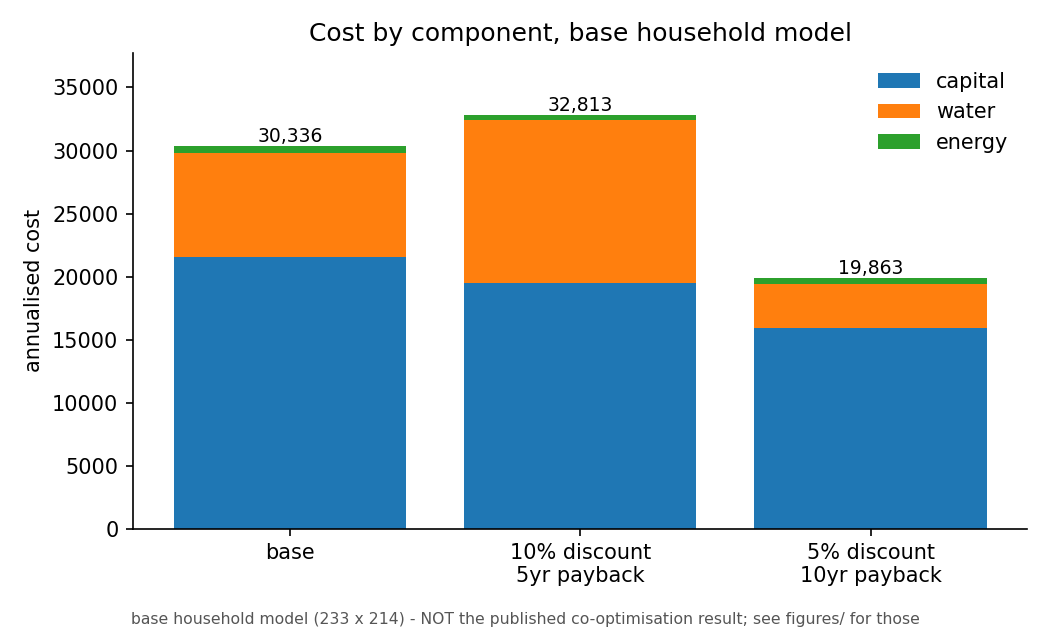

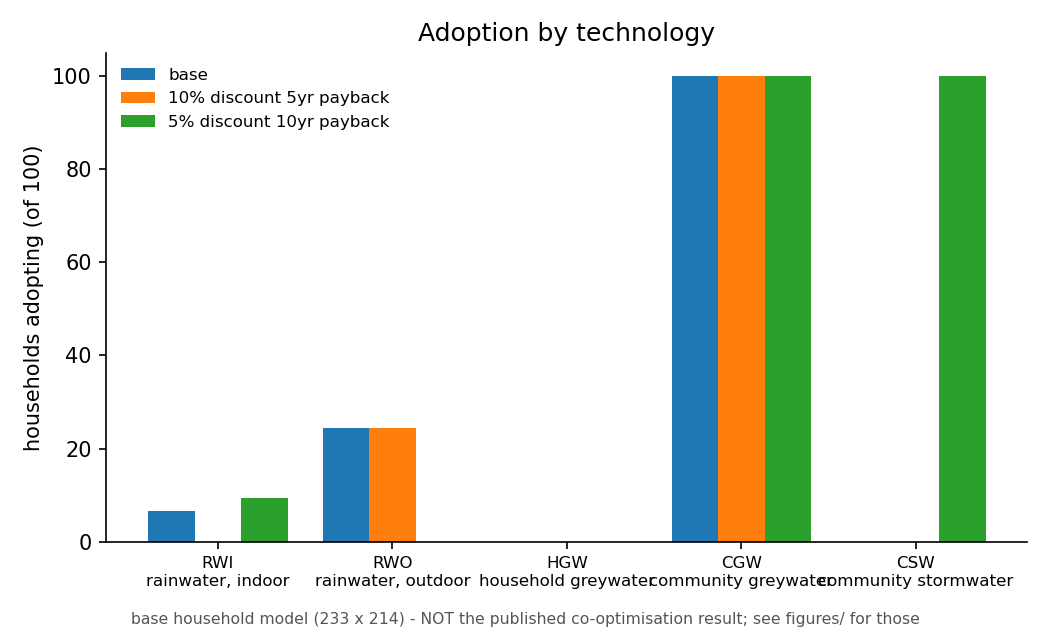

In [9]:
from pathlib import Path
from IPython.display import Image, display

BASE = "https://raw.githubusercontent.com/sear-labs/water-energy-coopt-scs-2021/v1.0.0"
for name in ("cost_by_component", "adoption_by_technology"):
    local = Path.cwd().parent / "results" / "figures" / f"{name}.png"
    display(Image(filename=str(local)) if local.exists()
            else Image(url=f"{BASE}/results/figures/{name}.png"))

---

**Cite the paper**, not this notebook:

> Jones, Erick C., Jr. "Co-optimization and community: Maximizing the benefits of distributed
> electricity and water technologies." *Sustainable Cities and Society*, 2021.
> [doi:10.1016/j.scs.2020.102515](https://doi.org/10.1016/j.scs.2020.102515)

`CITATION.cff` in the repository root carries both the software and the article.